In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as an
import sys
sys.path.append('/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/')

from inflapy.immunoFunc import *

In [2]:
path = "/nfs/team205/bh14/Datasets/RawData/raw_and_AnnData/annDataModified/"

s_path = "/nfs/team205/bh14/Datasets/Remapped/raw_adata/ummapped/"

#### JIA_Martin dataset

In [3]:
adata = sc.read_h5ad(path+"martin_JIA_modified.h5ad")

In [4]:
adata.obs

,donor_id,disease,tissue,dataset_id
AAACCTGAGAACAATC-1_0,5028STDY7152014,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
AAACCTGCAAACGCGA-1_0,5028STDY7152014,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
AAACCTGCAAGGGTCA-1_0,5028STDY7152014,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
AAACCTGCACTGTGTA-1_0,5028STDY7152014,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
AAACCTGCAGGAACGT-1_0,5028STDY7152014,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
...,...,...,...,...
TTTGTCATCCAAACTG-1_7,5028STDY7152012,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
TTTGTCATCCGCGTTT-1_7,5028STDY7152012,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
TTTGTCATCCTCTAGC-1_7,5028STDY7152012,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
TTTGTCATCGCGGATC-1_7,5028STDY7152012,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019


In [5]:
np.unique(adata.obs.donor_id)

array(['5028STDY7152010', '5028STDY7152011', '5028STDY7152012',
       '5028STDY7152013', '5028STDY7152014', '5028STDY7152015',
       '5028STDY7152016', '5028STDY7152017'], dtype=object)

In [6]:
jia_meta = pd.read_csv(s_path+"JIA_Martin.csv", index_col=0)

In [7]:
jia_meta

,Sample.ID,donor_id,tissue,cell_source,sex
5028STDY7152010_AAACCTGAGAATTCCC,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
5028STDY7152010_AAACCTGAGCGGATCA,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
5028STDY7152010_AAACCTGAGCTGCGAA,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
5028STDY7152010_AAACCTGAGCTTTGGT,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
5028STDY7152010_AAACCTGAGTAGGCCA,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
...,...,...,...,...,...
5028STDY7152017_TTTGTCACAGGGATTG,5028STDY7152017,PA513_2_SF_2,Synovial fluid,SF,Male
5028STDY7152017_TTTGTCACATCTCCCA,5028STDY7152017,PA513_2_SF_2,Synovial fluid,SF,Male
5028STDY7152017_TTTGTCACATGGTAGG,5028STDY7152017,PA513_2_SF_2,Synovial fluid,SF,Male
5028STDY7152017_TTTGTCAGTGATAAAC,5028STDY7152017,PA513_2_SF_2,Synovial fluid,SF,Male


In [8]:
adata.obs.iloc[:,0:2]

,donor_id,disease
AAACCTGAGAACAATC-1_0,5028STDY7152014,Oligoarticular JIA
AAACCTGCAAACGCGA-1_0,5028STDY7152014,Oligoarticular JIA
AAACCTGCAAGGGTCA-1_0,5028STDY7152014,Oligoarticular JIA
AAACCTGCACTGTGTA-1_0,5028STDY7152014,Oligoarticular JIA
AAACCTGCAGGAACGT-1_0,5028STDY7152014,Oligoarticular JIA
...,...,...
TTTGTCATCCAAACTG-1_7,5028STDY7152012,Oligoarticular JIA
TTTGTCATCCGCGTTT-1_7,5028STDY7152012,Oligoarticular JIA
TTTGTCATCCTCTAGC-1_7,5028STDY7152012,Oligoarticular JIA
TTTGTCATCGCGGATC-1_7,5028STDY7152012,Oligoarticular JIA


In [9]:
jia_meta.reset_index(drop=True)

,Sample.ID,donor_id,tissue,cell_source,sex
0,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
1,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
2,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
3,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
4,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
...,...,...,...,...,...
45577,5028STDY7152017,PA513_2_SF_2,Synovial fluid,SF,Male
45578,5028STDY7152017,PA513_2_SF_2,Synovial fluid,SF,Male
45579,5028STDY7152017,PA513_2_SF_2,Synovial fluid,SF,Male
45580,5028STDY7152017,PA513_2_SF_2,Synovial fluid,SF,Male


In [10]:
jia_meta.drop_duplicates(inplace=True)

In [11]:
jia_meta

,Sample.ID,donor_id,tissue,cell_source,sex
5028STDY7152010_AAACCTGAGAATTCCC,5028STDY7152010,PA547_2_PBMCS,Blood,PBMCS,Female
5028STDY7152011_AAACCTGAGACCTTTG,5028STDY7152011,PA547_2_PBMCS_2,Blood,PBMCS,Female
5028STDY7152012_AAACCTGAGATCCTGT,5028STDY7152012,PA547_2_SF,Synovial fluid,SF,Female
5028STDY7152013_AAACCTGAGTACGATA,5028STDY7152013,PA547_2_SF_2,Synovial fluid,SF,Female
5028STDY7152014_AAACCTGAGAACAATC,5028STDY7152014,PA513_2_PBMCS,Blood,PBMCS,Male
5028STDY7152015_AAACCTGAGACAAAGG,5028STDY7152015,PA513_2_PBMCS_2,Blood,PBMCS,Male
5028STDY7152016_AAACCTGCAGCTGTGC,5028STDY7152016,PA513_2_SF,Synovial fluid,SF,Male
5028STDY7152017_AAACCTGCAACGATCT,5028STDY7152017,PA513_2_SF_2,Synovial fluid,SF,Male


In [12]:
jia_meta.replace(["SF"], ["Synovial fluid"], inplace=True)

In [13]:
jia_meta.set_index(keys="Sample.ID", inplace=True)

In [14]:
jia_meta.dtypes

donor_id       object
tissue         object
cell_source    object
sex            object
dtype: object

In [15]:
merged_obs = adata.obs

In [16]:
merged_obs

,donor_id,disease,tissue,dataset_id
AAACCTGAGAACAATC-1_0,5028STDY7152014,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
AAACCTGCAAACGCGA-1_0,5028STDY7152014,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
AAACCTGCAAGGGTCA-1_0,5028STDY7152014,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
AAACCTGCACTGTGTA-1_0,5028STDY7152014,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
AAACCTGCAGGAACGT-1_0,5028STDY7152014,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
...,...,...,...,...
TTTGTCATCCAAACTG-1_7,5028STDY7152012,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
TTTGTCATCCGCGTTT-1_7,5028STDY7152012,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
TTTGTCATCCTCTAGC-1_7,5028STDY7152012,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019
TTTGTCATCGCGGATC-1_7,5028STDY7152012,Oligoarticular JIA,Mononuclear cells,Martin_JIA_2019


In [17]:
jia_meta.index[0]

'5028STDY7152010'

In [18]:

jia_meta.sex[merged_obs.donor_id[0]]

'Male'

In [19]:
merged_obs["sex"]=np.nan
merged_obs["cell_source"]=np.nan

In [20]:
merged_obs.dtypes

donor_id       category
disease        category
tissue         category
dataset_id     category
sex             float64
cell_source     float64
dtype: object

In [21]:
merged_obs.tissue = merged_obs.tissue.astype("str")

In [22]:
merged_obs["cell_source"] = ""
merged_obs["sex"] = ""

In [23]:
for i in range(merged_obs.shape[0]):
    donor=merged_obs.donor_id[i]
    tissue=jia_meta.tissue[merged_obs.donor_id[i]]
    sex=jia_meta.sex[merged_obs.donor_id[i]]
    
    merged_obs.tissue[i] = tissue
    
    merged_obs["sex"].iloc[i] = sex
    
    if tissue == "Blood":
        merged_obs["cell_source"].iloc[i] = "PBMC"
    else:
        merged_obs['cell_source'].iloc[i] = "Sorted CD45"

<ipython-input-23-648f42ca7d00>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_obs.tissue[i] = tissue
<ipython-input-23-648f42ca7d00>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_obs["sex"].iloc[i] = sex
<ipython-input-23-648f42ca7d00>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_obs["cell_source"].iloc[i] = "PBMC"
<ipython-input-23-648f42ca7d00>:13: SettingWithCopyWarning: 
A value is trying to be set o

In [24]:
merged_obs.dtypes

donor_id       category
disease        category
tissue           object
dataset_id     category
sex              object
cell_source      object
dtype: object

In [25]:
merged_obs.tissue = merged_obs.tissue.astype('category')
merged_obs.sex = merged_obs.sex.astype('category')
merged_obs.cell_source = merged_obs.cell_source.astype('category')

In [26]:
merged_obs[["tissue", "sex", "cell_source"]].value_counts()

tissue          sex     cell_source
Blood           Female  PBMC           14085
Synovial fluid  Female  Sorted CD45    13489
Blood           Male    PBMC           11058
Synovial fluid  Male    Sorted CD45     6460
dtype: int64

In [27]:
adata.obs = merged_obs

In [28]:
adata.obs["development_stage"] = np.repeat("Paediatric", adata.n_obs)

In [29]:
adata.obs

,donor_id,disease,tissue,dataset_id,sex,cell_source,development_stage
AAACCTGAGAACAATC-1_0,5028STDY7152014,Oligoarticular JIA,Blood,Martin_JIA_2019,Male,PBMC,Paediatric
AAACCTGCAAACGCGA-1_0,5028STDY7152014,Oligoarticular JIA,Blood,Martin_JIA_2019,Male,PBMC,Paediatric
AAACCTGCAAGGGTCA-1_0,5028STDY7152014,Oligoarticular JIA,Blood,Martin_JIA_2019,Male,PBMC,Paediatric
AAACCTGCACTGTGTA-1_0,5028STDY7152014,Oligoarticular JIA,Blood,Martin_JIA_2019,Male,PBMC,Paediatric
AAACCTGCAGGAACGT-1_0,5028STDY7152014,Oligoarticular JIA,Blood,Martin_JIA_2019,Male,PBMC,Paediatric
...,...,...,...,...,...,...,...
TTTGTCATCCAAACTG-1_7,5028STDY7152012,Oligoarticular JIA,Synovial fluid,Martin_JIA_2019,Female,Sorted CD45,Paediatric
TTTGTCATCCGCGTTT-1_7,5028STDY7152012,Oligoarticular JIA,Synovial fluid,Martin_JIA_2019,Female,Sorted CD45,Paediatric
TTTGTCATCCTCTAGC-1_7,5028STDY7152012,Oligoarticular JIA,Synovial fluid,Martin_JIA_2019,Female,Sorted CD45,Paediatric
TTTGTCATCGCGGATC-1_7,5028STDY7152012,Oligoarticular JIA,Synovial fluid,Martin_JIA_2019,Female,Sorted CD45,Paediatric


In [30]:
#adata[adata.obs["cell_source"]=="PBMC"].write_h5ad(s_path+"PBMC/Martin_JIA_PBMC.h5ad")

#adata[adata.obs["cell_source"]!="PBMC"].write_h5ad(s_path+"Tissue/Martin_JIA_Synovial_fluid.h5ad")

In [31]:
gc.collect()

136

In [32]:
### Quality control

#####################################################
###                      Martin_JIA_PBMC.h5ad                 ###
######################################################
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.27
Detected doublet rate = 4.0%
Estimated detectable doublet fraction = 66.9%
Overall doublet rate:
	Expected   = 7.6%
	Estimated  = 6.0%
Elapsed time: 75.6 seconds


/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/inflapy/immunoFunc.py:363: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['doublet_scores'], adata.obs['predicted_doublets'] = scrub.scrub_doublets(min_counts=2, min_cells=3, min_gene_variability_pctl=85, n_prin_comps=30)


Pass            24113
Doublet          1016
High_MT             8
Low_nFeature        6
Name: QC, dtype: int64
Plot of metadata only for cells that pass tentative QC:  



/home/jovyan/my-conda-envs/autoimmune/lib/python3.8/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


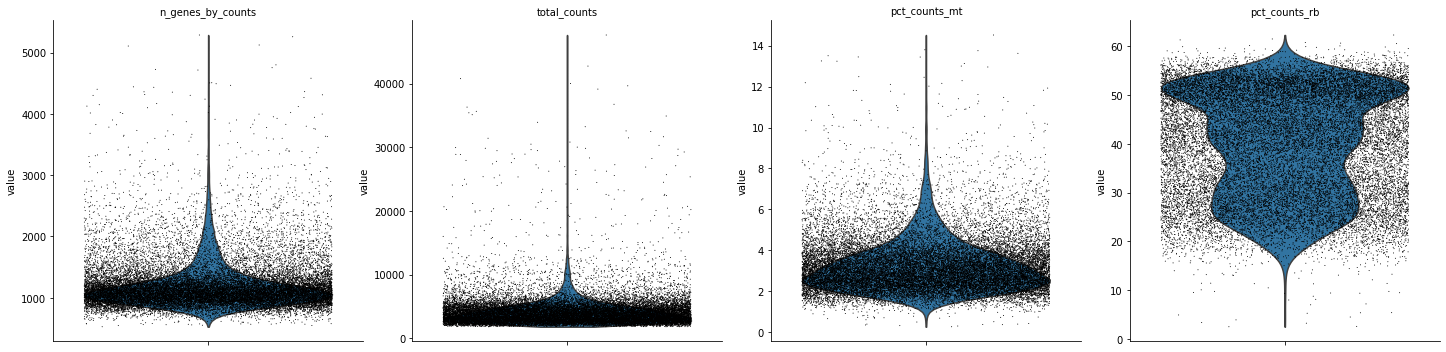

In [33]:
adataQc(adata=adata[adata.obs["cell_source"]=="PBMC"], path=s_path+"PBMC/QC_Doublet/", file="Martin_JIA_PBMC.h5ad")

#####################################################
###                      Martin_JIA_Synovial_fluid.h5ad                 ###
######################################################
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.78
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 2.2%
Overall doublet rate:
	Expected   = 7.6%
	Estimated  = 0.7%
Elapsed time: 40.7 seconds


/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/inflapy/immunoFunc.py:363: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['doublet_scores'], adata.obs['predicted_doublets'] = scrub.scrub_doublets(min_counts=2, min_cells=3, min_gene_variability_pctl=85, n_prin_comps=30)


Pass            19933
High_MT            12
Doublet             3
Low_nFeature        1
Name: QC, dtype: int64
Plot of metadata only for cells that pass tentative QC:  



/home/jovyan/my-conda-envs/autoimmune/lib/python3.8/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


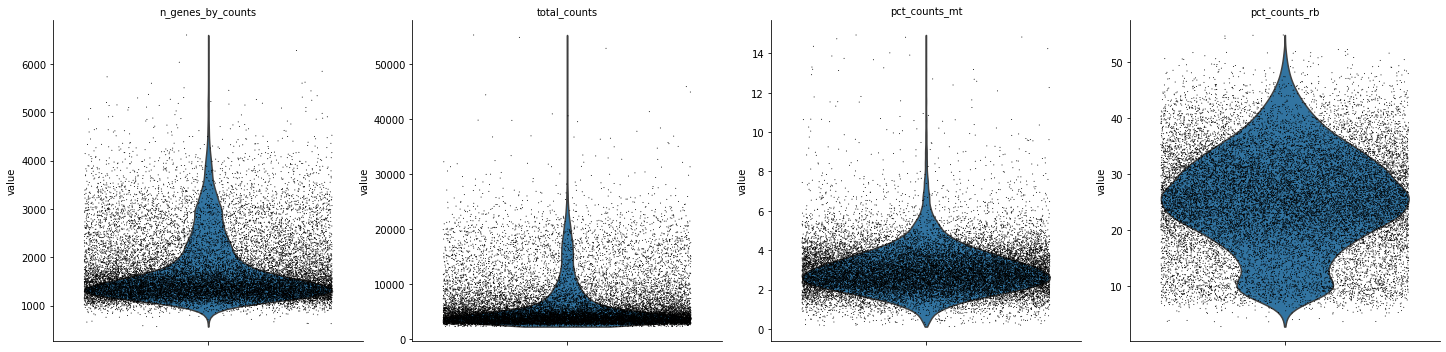

In [34]:
adataQc(adata=adata[adata.obs["cell_source"]!="PBMC"], path=s_path+"Tissue/QC_Doublet/", file="Martin_JIA_Synovial_fluid.h5ad")


In [35]:
adata.obs.donor_id.value_counts()

5028STDY7152010    8180
5028STDY7152012    6904
5028STDY7152013    6585
5028STDY7152011    5905
5028STDY7152015    5655
5028STDY7152014    5403
5028STDY7152017    3235
5028STDY7152016    3225
Name: donor_id, dtype: int64